In [4]:
import numpy as np
import pandas as pd

In [20]:
df =  pd.read_csv("placement.csv")

In [21]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [22]:
df.shape  # 100 days  and 4 columns

(100, 4)

## STEPS

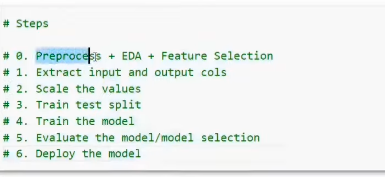

In [23]:
df  = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


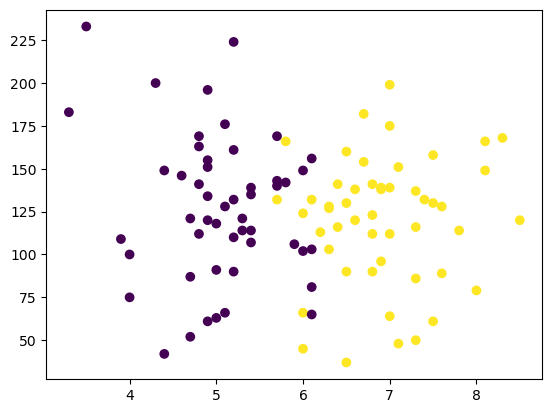

In [28]:
# EDA

import matplotlib.pyplot as plt

plt.scatter(df["cgpa"],df["iq"],c=df['placement'])

In [38]:
# extracting input/output columns
X = df.iloc[:,0:2] # saare rows but columns from 0 to 2
y = df.iloc[:,-1]



In [44]:
# train to split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size = 0.1)  # it means 10% on testing and 90% on training set


In [57]:
# Scaling the value
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_train

array([[ 0.30839735, -0.16870685],
       [-1.81306214, -0.55991113],
       [-1.45948555, -1.97802664],
       [-0.04517923, -1.39122022],
       [-1.10590897,  0.98045573],
       [ 1.10394466, -0.90221487],
       [-0.75233239, -0.31540845],
       [-0.75233239,  2.47192205],
       [-0.04517923,  0.63815198],
       [-0.66393825, -0.04645551],
       [ 0.92715637, -1.83132504],
       [ 0.66197393, -0.26650792],
       [-0.75233239,  0.22249743],
       [-1.5478797 ,  1.88511563],
       [-0.92912068, -0.77996353],
       [ 1.81109782,  1.05380653],
       [ 0.48518564, -0.07090578],
       [-1.01751483, -1.51347156],
       [ 0.3967915 ,  0.90710493],
       [ 0.75036808,  0.36919904],
       [-0.84072654, -1.39122022],
       [ 0.3967915 ,  0.1735969 ],
       [ 0.3967915 , -2.10027798],
       [-0.84072654,  0.12469636],
       [ 0.22000321,  0.1002461 ],
       [ 1.1923388 ,  0.22249743],
       [ 0.22000321,  0.12469636],
       [ 0.48518564,  0.36919904],
       [ 0.13160906,

In [100]:
X_test = scaler.fit_transform(X_test)
X_test

array([[ 1.57000518,  0.        ],
       [ 0.23787957,  0.        ],
       [ 1.28454969,  0.        ],
       [-1.37970152,  0.        ],
       [-0.23787957,  0.        ],
       [-0.9990942 ,  0.        ],
       [ 1.28454969,  0.        ],
       [-0.80879055,  0.        ],
       [-0.23787957,  0.        ],
       [-0.71363872,  0.        ]])

In [101]:
# train the model

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

# model training

clf.fit(X_train,y_train)

LogisticRegression()

In [110]:
# Model Evaluation

y_pred  = clf.predict(X_test)

In [109]:
y_test

21    1
36    0
43    1
68    0
28    0
88    0
0     1
39    0
47    0
24    0
Name: placement, dtype: int64

In [111]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9

In [115]:
from mlxtend.plotting import plot_decision_regions


<Axes: >

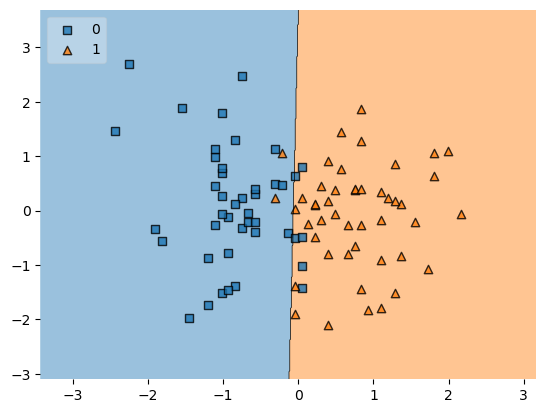

In [116]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)


In [117]:
import pickle


In [118]:
pickle.dump(clf,open("model.pkl","wb"))